# Logistic Regression for a Binary Classification of Images

## import library

In [ ]:
import sys
! python -m pip install --upgrade pip
! pip install -r requirements.txt

In [2]:
import os
from pyexpat import model
import torch
from torchvision import transforms
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import statistics

In [3]:
from MyDataset import MyDataset
from MyEval import MyEval
from MyModel import MyModel
from MyOptim import MyOptim
from MyResult import MyResult

## construct dataset 

In [4]:
dataset = MyDataset(path='data', split='train')

## construct dataloader

In [5]:
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, drop_last=True, shuffle=True)

## plot the dataset

In [6]:
iter_data       = iter(dataloader)
(data, label)   = next(iter_data)
print(data.shape, label.shape)
print(data.dtype, label.dtype)

torch.Size([64, 1, 32, 32]) torch.Size([64])
torch.float32 torch.uint8


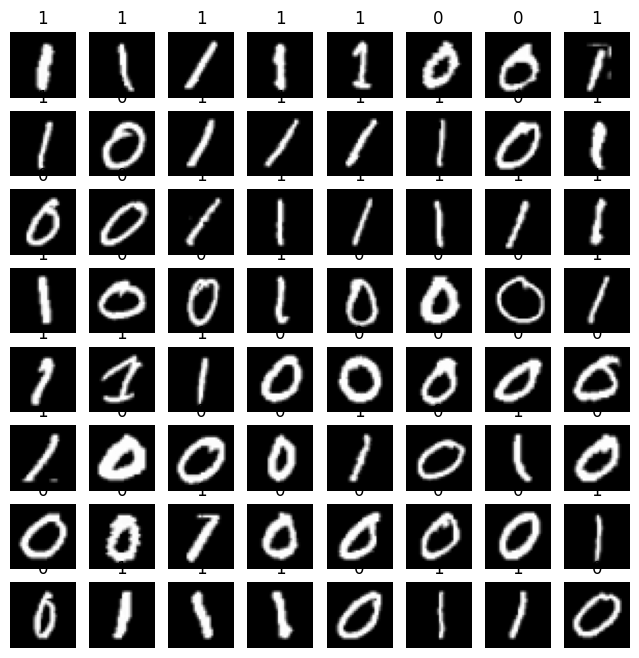

In [7]:
nRow = 8
nCol = 8
plt.figure(figsize=(nRow, nCol))
for i in range(nRow):
    for j in range(nCol):
        idx = nCol * i + j
        plt.subplot(nRow, nCol, idx+1)
        plt.axis('off')
        plt.title(f'{int(label[idx])}')
        plt.imshow(data[idx].squeeze(0), cmap='gray')
plt.show()

## flatten data

In [8]:
vec = nn.Flatten()(data)
print(data.shape, data.dtype)
print(vec.shape, vec.dtype)

torch.Size([64, 1, 32, 32]) torch.float32
torch.Size([64, 1024]) torch.float32


## construct model

In [9]:
shape_vec   = vec.shape
dim_input   = shape_vec[1]
model       = MyModel()
size_model  = model.size()
print('model size =', size_model)
print('dimension of the data =', dim_input)

weight: torch.Size([1024, 1]), torch.float32
model size = 1024
dimension of the data = 1024


## train

In [ ]:
eval    = MyEval()
optim   = MyOptim()
result  = MyResult()

model.train()
num_epoch = 10

for epoch in range(num_epoch):
    loss_epoch      = []
    accuracy_epoch  = []

    for step, (data, label) in enumerate(tqdm(dataloader)):
        loss_batch      = []
        accuracy_batch  = []
        
        vec     = nn.Flatten()(data)
        pred    = model(vec)

        # print(pred.shape, label.shape)
        # print(pred.dtype, label.dtype)
        
        pred        = pred.view(-1)
        label       = label.view(-1)
        accuracy_value = eval.compute_accuracy(pred, label)
        loss_value  = accuracy_value

        # print(pred.shape, label.shape)
        # print(pred.dtype, label.dtype)
        
        loss_batch.append(loss_value.item())
        accuracy_batch.append(accuracy_value.item())

    loss_epoch.append(statistics.mean(loss_batch))
    accuracy_epoch.append(statistics.mean(accuracy_batch))

    print(f'Epoch {epoch+1}/{num_epoch}, Loss: {sum(loss_epoch)/len(loss_epoch)}, Accuracy: {sum(accuracy_epoch)/len(accuracy_epoch)}')

accuracy_train = statistics.mean(accuracy_epoch)
result.add_result('train', accuracy_train)

## save the trained model

In [11]:
model.eval()
model.save()

## test

In [ ]:
eval    = MyEval()
result  = MyResult()
model   = MyModel()
model.load()

batch_size  = 64
dataset     = MyDataset(path='data', split='train')
dataloader  = DataLoader(dataset, batch_size=batch_size, drop_last=False, shuffle=False)

accuracy_batch = []

for step, (data, label) in enumerate(tqdm(dataloader)):
    vec     = nn.Flatten()(data)
    pred    = model(vec)

    pred    = pred.view(-1)
    label   = label.view(-1)
    accuracy_value = eval.compute_accuracy(pred, label)
    accuracy_batch.append(accuracy_value.item())

accuracy_test = statistics.mean(accuracy_batch)
result.add_result('test', accuracy_test)

## save results

In [14]:
result.save()